# Whisper-medium — fine-tuning encoder

**Модель:** Whisper-medium encoder (верхние N слоёв разморожены) + classification head

```
Whisper encoder (24 слоя)
  └── Нижние 20 слоёв: заморожены
  └── Верхние 4 слоя: обучаемые
  ↓
Mean pooling → Dropout → Linear(1024 + n_letters, 2)
```

**Whisper-medium vs small:**
- d_model: 1024 (vs 768)
- encoder layers: 24 (vs 12)
- ~307M параметров всего (vs ~244M)
- batch_size уменьшен до 4 из-за памяти GPU

In [7]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import time
import mlflow
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
from transformers import WhisperModel, WhisperProcessor
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from shared.mlflow_utils import start_run, log_epoch, log_artifact_if_exists

train_utils.set_seed(config.RANDOM_STATE)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:0


In [8]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_holdout_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,  paths_val  = paths_trainval[idx_tr],  paths_trainval[idx_val]
labels_train, labels_val = labels_trainval[idx_tr], labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")


Train: 1931, Val: 425, Test: 416


In [9]:
MODEL_ID = "openai/whisper-medium"
print(f"Device: {DEVICE}")

processor = WhisperProcessor.from_pretrained(MODEL_ID)

class WhisperDataset(Dataset):
    def __init__(self, paths, labels, letters, augment=False):
        self.paths = paths
        self.labels = labels
        self.letters = letters
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        y, sr = data_utils.load_audio(self.paths[i], sr=16000)
        feats = processor.feature_extractor(
            y, sampling_rate=16000, return_tensors="np"
        ).input_features[0]  # (80, 3000)
        if self.augment:
            feats = data_utils.augment_mel_spectrogram(feats)
        return (
            torch.from_numpy(feats).float(),
            torch.from_numpy(self.letters[i]).float(),
            int(self.labels[i]),
        )

BATCH_SIZE = 4  # уменьшен по сравнению со small (8) из-за большего размера модели
train_loader = DataLoader(
    WhisperDataset(paths_train, labels_train, letters_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    WhisperDataset(paths_val, labels_val, letters_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    WhisperDataset(paths_test, labels_test, letters_test, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)


Device: cuda:0


In [10]:
N_UNFREEZE = 4   # размораживаем верхние 4 из 24 слоёв
EMBED_DIM  = 1024  # Whisper-medium d_model
DROPOUT    = 0.3
N_EPOCHS   = 30

class WhisperClassifier(nn.Module):
    def __init__(self, whisper_model, n_letters=0, dropout=DROPOUT, n_unfreeze=N_UNFREEZE):
        super().__init__()
        self.encoder = whisper_model.encoder
        self.n_letters = n_letters

        for p in self.encoder.parameters():
            p.requires_grad = False

        n_layers = len(self.encoder.layers)
        for layer in self.encoder.layers[n_layers - n_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.encoder.layer_norm.parameters():
            p.requires_grad = True

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(EMBED_DIM + n_letters, 2)

        n_frozen = sum(not p.requires_grad for p in self.encoder.parameters())
        n_train  = sum(p.requires_grad for p in self.parameters())
        print(f"Encoder параметров замороженных: {n_frozen}")
        print(f"Всего обучаемых параметров: {n_train}")

    def forward(self, input_features, letters=None):
        hidden = self.encoder(input_features).last_hidden_state
        pooled = hidden.mean(dim=1)
        pooled = self.dropout(pooled)
        if self.n_letters > 0 and letters is not None:
            pooled = torch.cat([pooled, letters], dim=1)
        return self.head(pooled)


whisper_model = WhisperModel.from_pretrained(MODEL_ID)
n_letters = letters_train.shape[1]
model = WhisperClassifier(whisper_model, n_letters=n_letters, n_unfreeze=N_UNFREEZE).to(DEVICE)
n_params_total     = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {n_params_total:,}  |  Обучаемых: {n_params_trainable:,}")


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

Encoder параметров замороженных: 305
Всего обучаемых параметров: 64

Всего параметров: 307,218,452  |  Обучаемых: 50,384,916


In [11]:
with start_run("exp_whisper_medium_finetune", group="04_pretrained_finetuned"):

    mlflow.log_params({
        "encoder":          MODEL_ID,
        "n_unfreeze":       N_UNFREEZE,
        "embed_dim":        EMBED_DIM,
        "dropout":          DROPOUT,
        "n_epochs":         N_EPOCHS,
        "batch_size":       BATCH_SIZE,
        "lr_encoder":       2e-5,
        "lr_head":          1e-4,
        "augment":          "SpecAugment",
        "class_weight":     "balanced",
        "early_stopping_patience": config.EARLY_STOPPING_PATIENCE,
        "num_params_trainable": n_params_trainable,
    })

    weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))

    encoder_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and 'head' not in n]
    head_params    = list(model.head.parameters())
    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": 2e-5, "weight_decay": 1e-4},
        {"params": head_params,    "lr": 1e-4, "weight_decay": 1e-4},
    ])
    scheduler = train_utils.get_lr_scheduler(optimizer)
    early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
    best_ckpt = exp_dir / "best_ckpt.pt"
    best_f1 = -1.0

    def eval_loader(loader):
        model.eval()
        logits_list, true_list = [], []
        with torch.no_grad():
            for feats, letters, y in loader:
                logits = model(feats.to(DEVICE), letters.to(DEVICE))
                logits_list.append(logits.cpu().numpy())
                true_list.extend(y.tolist())
        logits = np.concatenate(logits_list)
        proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
        return proba, np.array(true_list)

    train_losses, val_f1s = [], []
    t0 = time.perf_counter()

    for epoch in range(N_EPOCHS):
        model.train()
        losses = []
        for feats, letters, y in train_loader:
            feats, letters, y = feats.to(DEVICE), letters.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(feats, letters), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        val_proba, val_true = eval_loader(val_loader)
        val_f1 = _f1(val_true, (val_proba >= 0.5).astype(int), average="macro")
        val_f1s.append(val_f1)

        log_epoch(epoch, train_loss=train_loss, val_f1_macro=val_f1,
                  lr=optimizer.param_groups[0]["lr"])

        if val_f1 > best_f1:
            best_f1 = val_f1
            train_utils.save_best_checkpoint(model, best_ckpt)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}")
        if early_stopping.step(val_f1):
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_time_sec = time.perf_counter() - t0
    _run_id = mlflow.active_run().info.run_id


Epoch 1/30  loss=0.6442  val_f1=0.6905
Epoch 2/30  loss=0.5465  val_f1=0.7914
Epoch 3/30  loss=0.4824  val_f1=0.7899
Epoch 4/30  loss=0.4073  val_f1=0.7907
Epoch 5/30  loss=0.3289  val_f1=0.7843
Epoch 6/30  loss=0.1982  val_f1=0.7430
Epoch 7/30  loss=0.1480  val_f1=0.7992
Epoch 8/30  loss=0.1505  val_f1=0.7802
Epoch 9/30  loss=0.1256  val_f1=0.7988
Epoch 10/30  loss=0.0910  val_f1=0.7492
Epoch 11/30  loss=0.1191  val_f1=0.7901
Epoch 12/30  loss=0.1035  val_f1=0.7853
Epoch 13/30  loss=0.0789  val_f1=0.7897
Epoch 14/30  loss=0.0375  val_f1=0.7823
Epoch 15/30  loss=0.0350  val_f1=0.7693
Epoch 16/30  loss=0.0286  val_f1=0.7746
Epoch 17/30  loss=0.0071  val_f1=0.7771
Early stopping на эпохе 17


## Сравнение с baseline и Whisper-small finetune

/home/dk/HSE_VKR_DetectingSpeechDefects/experiments/shared/train_utils.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



Обучение: 11239.6 с | best val_f1=0.7992
Оптимальный порог: 0.17
              precision    recall  f1-score   support

        good       0.88      0.88      0.88       281
         bad       0.75      0.75      0.75       135

    accuracy                           0.84       416
   macro avg       0.81      0.81      0.81       416
weighted avg       0.84      0.84      0.84       416

Threshold : 0.17
Accuracy  : 0.8365
F1-macro  : 0.8136
F1-bad    : 0.7481
ROC-AUC   : 0.8637


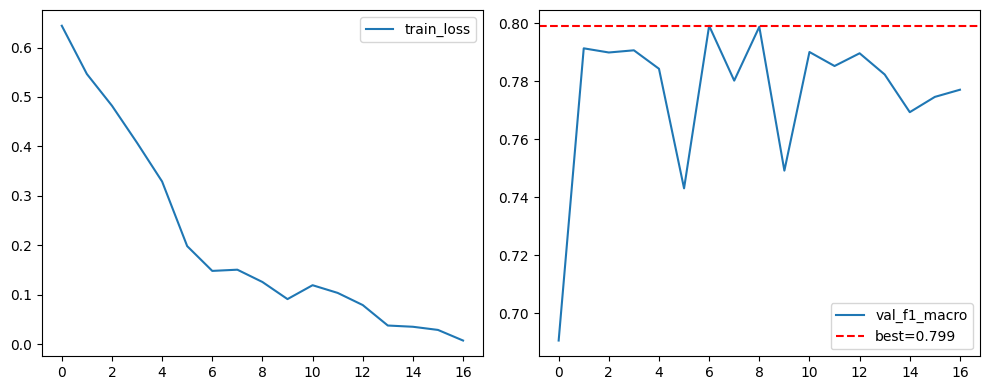

Результаты сохранены


,Accuracy,F1-macro,F1-bad,ROC-AUC
Модель,,,,
Whisper-small frozen + SVM (exp_30),0.8300,0.7990,0.7220,0.8900
Whisper-small finetune (4 слоя),NaN,NaN,NaN,NaN
Whisper-medium finetune (4 слоя) [этот эксперимент],0.8365,0.8136,0.7481,0.8637


In [12]:
train_utils.load_best_checkpoint(model, best_ckpt, DEVICE)

print(f"\nОбучение: {train_time_sec:.1f} с | best val_f1={best_f1:.4f}")

with mlflow.start_run(run_id=_run_id):
    val_proba, val_true = eval_loader(val_loader)
    optimal_threshold = find_optimal_threshold(val_true, val_proba)
    print(f"Оптимальный порог: {optimal_threshold:.2f}")

    test_proba, test_true = eval_loader(test_loader)
    test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)
    pd.DataFrame({
        "path":    paths_test,
        "y_true":  test_true,
        "y_pred":  (test_proba >= optimal_threshold).astype(int),
        "y_proba": test_proba,
    }).to_csv(exp_dir / "test_predictions.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
    axes[1].plot(val_f1s, label="val_f1_macro")
    axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}")
    axes[1].legend()
    plt.tight_layout()
    fig.savefig(exp_dir / "training_curves.png", dpi=120)
    plt.show()

    save_result_csv(
        exp_dir=exp_dir,
        experiment_id="exp_whisper_medium_finetune",
        experiment_name=f"Whisper-medium fine-tuning (верхние {N_UNFREEZE} слоя)",
        model="WhisperClassifier (partial finetune, medium)",
        accuracy=test_metrics["accuracy"],
        f1_macro=test_metrics["f1_macro"],
        f1_bad=test_metrics["f1_bad"],
        roc_auc=test_metrics["roc_auc"],
        precision_bad=test_metrics["precision_bad"],
        recall_bad=test_metrics["recall_bad"],
        threshold=test_metrics["threshold"],
        embed_dim=1024,
        embed_dim_note="Whisper-medium encoder 1024-dim, mean pooling → head=Linear(1024+n_letters, 2)",
        notes=(
            f"SpecAugment + partial finetune | "
            f"n_unfreeze={N_UNFREEZE}/24 | lr_encoder=2e-5 lr_head=1e-4 | "
            f"batch={BATCH_SIZE} | thr={optimal_threshold:.2f}"
        ),
        num_params=n_params_trainable,
        train_time_sec=train_time_sec,
    )
    log_artifact_if_exists(exp_dir / "training_curves.png")
    print("Результаты сохранены")

comparison = pd.DataFrame([
    {"Модель": "Whisper-small frozen + SVM (exp_30)",
     "Accuracy": 0.830, "F1-macro": 0.799, "F1-bad": 0.722, "ROC-AUC": 0.890},
    {"Модель": f"Whisper-small finetune ({N_UNFREEZE} слоя)",
     "Accuracy": None, "F1-macro": None, "F1-bad": None, "ROC-AUC": None},
    {"Модель": f"Whisper-medium finetune ({N_UNFREEZE} слоя) [этот эксперимент]",
     "Accuracy": test_metrics["accuracy"],
     "F1-macro": test_metrics["f1_macro"],
     "F1-bad":   test_metrics["f1_bad"],
     "ROC-AUC":  test_metrics["roc_auc"]},
])
display(comparison.set_index("Модель").round(4))
